# Model Pipeline: ISYE 6740 Final Project

In [297]:
#==============================================#
# IMPORT MODULES
#==============================================#
import pandas as pd
import numpy as np
import openpyxl
from iosacal import R, combine, iplot
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import arviz_plots as azp

## Data Acquisition
Data Acquisition. The dataset consists of ~475 radiocarbon measurements collected over 50 years of archaeological fieldwork by the Smithsonian Institution. The radiocarbon assays include geographic metadata, sample material, and cultural attribution.

To reduce the risk of exposing sensitive archaeological site locations and preserve the integrity of these irreplaceable cultural resources, all site spatial coordinates will be perturbed or aggregated prior to inclusion in the report and model pipeline. This was accomplished prior to loading the dataset. 



In [66]:
#==============================================#
# IMPORT AND CLEAN DATA
#==============================================#
radiocarbon = pd.read_excel("radiocarbon.xlsx")

# Remove samples from none-cultural sources (e.g., sediment cores).
# Samples with "Geological Sample" or "Pollen Core" in "GenProv" are considered non-cultural.
radiocarbon = radiocarbon[~radiocarbon['GenProv']
                .str.contains("POLLEN CORE|GEOLOGICAL SAMPLE", case=False)]

# Samples prior to 80000 BP removed. 
# 70000 BP widely regarded as first reliable evidence of human occupation in the far southern part of the study region
radiocarbon = radiocarbon.iloc[radiocarbon["C14Date1"] < 8000]

print("Number of cultural samples available:", radiocarbon.shape[0])



Number of cultural samples available: 367


## Date Calibration. 

Radiocarbon dates will be calibrated to correct for temporal fluctuations in background atmospheric carbon-14 using the IntCal20 calibration curves (Reimer, 2020). Samples derived from terrestrial and marine sources must be calibrated separately to avoid carbon reservoir effects.

In [163]:
#==============================================#
# CALIBRATE RADIOCARBON DATA
#==============================================#
# Calibrate radiocarbon samples to calendar years based on samples of known age.
# Calibration is conducted using IOSACAL package: https://c14.iosa.it/en/latest/.
# Marine and terrestrial data should be calibrated seperately.
# Assumes that dates not marked as from a marine source are terrestrial.

# Identify marine dates
# keywords: marine, shell, fat, whale, seal
marine_radiocarbon = radiocarbon[radiocarbon['C14SampTyp']
                .str.contains("marine|shell|fat|whale|seal", case=False)]

# Identify terrestrial dates
terrestrial_radiocarbon = radiocarbon[~ radiocarbon['C14SampTyp']
                .str.contains("marine|shell|fat|whale|seal", case=False)]

# record earliest and latest calibrated dates
# will be used for creating date mesh
cal_early = -float('inf')

# Calibrate terrestrial samples according to IntCal20 calibration curve
# Create combined date object for calibration
terrestrial_cals = []
for row in terrestrial_radiocarbon.itertuples(index=True):
    uncal = R(row.C14Date1, row.C14Vari1, row.C14LabNo1) 
    cal = uncal.calibrate("intcal20").tolist()
    terrestrial_cals.append(cal)
    early_cand = np.max(cal[0])
    if early_cand > cal_early:
        cal_early = early_cand
    

# Calibrate marine samples according to Marine20 calibration curve
marine_cals = []
for row in marine_radiocarbon.itertuples(index=True):
    uncal = R(row.C14Date1, row.C14Vari1, row.C14LabNo1) 
    cal = uncal.calibrate("marine20").tolist()
    marine_cals.append(cal)
    early_cand = np.max(cal[0])

    if early_cand > cal_early:
        cal_early = early_cand
    


In [164]:
# Numpy date grid. 
# Number of rows = number of samples
# Number of columns = number of dates between most recently observed and last observed
# Transpose to create correct data structure
print(int(cal_early))
# First create the grid of zeros. 
# Iteratet the grid and add date to relevant position.
# Sparse matrix: Optimization might be required. 

calibrations = terrestrial_cals + marine_cals

calibrated_density_grid = np.zeros((radiocarbon.shape[0], int(cal_early)+1))

for index, date_list in enumerate(calibrations):
   for density_estimate in date_list:
       calibrated_density_grid[index, int(density_estimate[0])] = density_estimate[1]



10756


In [ ]:
# Trim calendar years and grid
calibrated_density_grid = calibrated_density_grid[:,500:8000]

# Define calendar years
calendar_years = np.arange(start=0,stop=calibrated_density_grid.shape[1])

## Oversampling Corrections. 

Dates-as-data can lead to biased estimates of population density due to intensive focus on certain productive archaeological sites. To reduce this bias, samples may be aggregated by site and temporal phase so as not to oversample key locations, following techniques commonly applied in archaeological demography (Crema 2018; Shennan et al., 2013). This methodology is still under discussion in the literature and may lack strong theoretical grounding.

In [ ]:
# Attack this later. Let's look at model estimation now. 
# https://www.cambridge.org/core/journals/cambridge-archaeological-journal/article/archaeological-and-genetic-foundations-of-the-european-population-during-the-late-glacial-implications-for-agricultural-thinking/1838A9994BEF630FE231867676CB3728
# https://www.sciencedirect.com/science/article/pii/S0305440306002330?via%3Dihub#bib12



## Mixture Model Estimation

Gaussian Mixture Model Estimates. Gaussian mixture models will be fit according to the procedure outlined in Price et al. (2018).

(array([48., 79., 57., 37., 50., 46., 18., 18., 11.,  3.]),
 array([ 100. ,  879.5, 1659. , 2438.5, 3218. , 3997.5, 4777. , 5556.5,
        6336. , 7115.5, 7895. ]),
 <BarContainer object of 10 artists>)

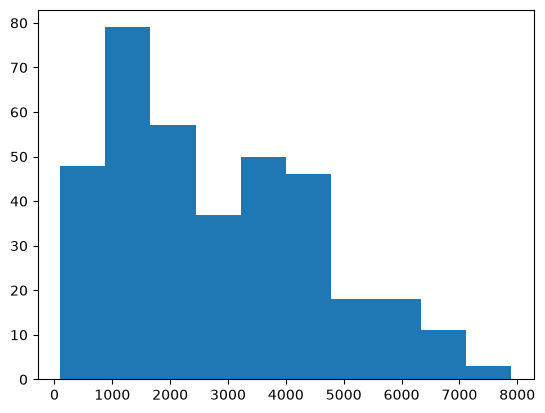

In [67]:
#==============================================#
# BAYESIAN ESTIMATION OF GAUSSIAN MIXTURE MODEL
#==============================================#
# PyMC used for mixture model training 
# Parameterize prior probabilities of mu.
# Parameterize prior probabilities of sigma.
# Parameterize prior probabilities of weight latent variables. 

In [341]:
#==============================================#
# BAYESIAN ESTIMATION OF GAUSSIAN MIXTURE MODEL
#==============================================#
# PyMC used for mixture model training 
# Parameterize prior probabilities of mu.
# Parameterize prior probabilities of sigma.
# Parameterize prior probabilities of weight latent variables. 




dates = radiocarbon["C14Date1"].values


t_min = np.min(dates)
t_max = np.max(dates)
k=2

basic_model = pm.Model()

with basic_model as model:

    # Set priors for mu and sigma. These are calculated a priori. 
    #mu = pm.Uniform("mu", lower=t_min, upper=t_max, shape=k)
    raw_mu = pm.Exponential("raw_mu", 1/1000, shape=k, transform=pm.distributions.transforms.ordered)

    mu = pm.Deterministic(
        "mu",
        500+raw_mu
    )

    sigma = pm.HalfNormal("sigma", sigma=250,shape=k)
    weights = pm.Dirichlet("w", np.ones(k)*3)
    

    calibration_density_i = pm.Data(
        "calibration_density",
        calibrated_density_grid
    )

    component_density = pm.math.exp(pm.logp(
        pm.Normal.dist(
            mu=mu[:, None],
            sigma = sigma[:,None]
        ),
        calendar_years
    )
    )

    mixture_density = pm.math.sum(component_density * weights[:,None], axis=0)

    product = calibration_density_i * mixture_density
    
    likelihood = pm.math.sum(product, axis=1)

    log_likelihood_i = pm.math.log(likelihood + 1e-12)

    pm.Potential("obs_i", pm.math.sum(log_likelihood_i))
    # Construct measurement matrix 

    pm.Deterministic(
        "mixture_density",
        mixture_density
    )
    
    idata = pm.sample(target_accept=0.95, random_seed=6740)


Initializing NUTS using jitter+adapt_diag...


SamplingError: Initial evaluation of model at starting point failed!
Starting values:
{'raw_mu_chain__': array([7.09275381,       -inf]), 'sigma_log__': array([4.91317995, 6.04176798]), 'w_simplex__': array([-0.79594123])}

Logp initial evaluation results:
{'raw_mu': np.float64(-inf), 'sigma': np.float64(-2.1), 'w': np.float64(-1.79), 'obs_i': np.float64(-6030.42)}
You can call `model.debug()` for more details.

In [338]:
model.debug()

point={'mu_chain__': array([6.90775528,       -inf]), 'sigma_log__': array([5.52146092, 5.52146092]), 'w_simplex__': array([0.])}



TypeError: TensorType does not support iteration.
	Did you try to unpack a Variable or used a function that expects a list?


In [310]:
#==============================================#
# CONVERGENCE DIAGNOSTICS
#==============================================#
az.rcParams['plot.max_subplots']=100
div = idata.sample_stats["diverging"]

divergences = idata.sample_stats["diverging"].values

print(divergences.sum())

summary = az.summary(idata, var_names=["mu", "sigma", "w"])
summary

49


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[0],3e+03,2e+03,5.3,5400,7,18,1.58,790,330
mu[1],3e+03,2e+03,35,5500,30,39,1.16,280,170
mu[2],2e+03,2e+03,3.6,5500,10,21,1.32,560,300
mu[3],2e+03,2e+03,3.1,5100,13,22,1.27,410,280
mu[4],4e+03,2e+03,11,6300,9,7,1.40,720,290
sigma[0],6e+02,3e+02,130,1100,36,197,1.09,61,36
sigma[1],5e+02,4e+02,28,1100,13,7,1.25,95,56
sigma[2],5e+02,3e+02,200,1000,71,52,1.06,36,27
sigma[3],6e+02,3e+02,180,1100,49,114,1.07,53,33
sigma[4],6e+02,3e+02,190,1100,27,151,1.10,66,41


In [317]:
import arviz as az
print(az.__version__)
print(pm.__version__)

1.2.0
6.2.0


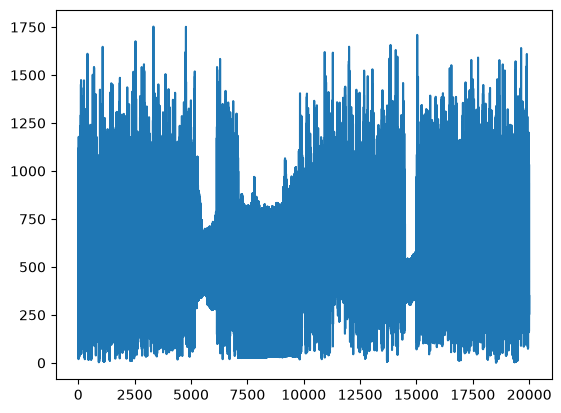

In [312]:
plt.plot(idata.posterior["sigma"].values.flatten())
plt.show()

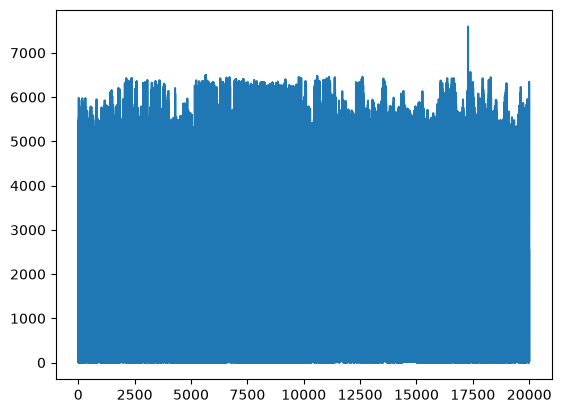

In [313]:
plt.plot(idata.posterior["mu"].values.flatten())
plt.show()

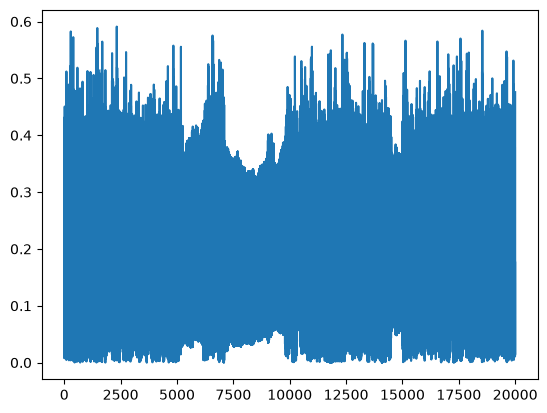

In [315]:
plt.plot(idata.posterior["w"].values.flatten())
plt.show()

In [ ]:
df = idata.posterior["w"].to_dataframe()
df.i

w
chain draw w_dim_0          
0     0    0        0.187090
           1        0.107223
           2        0.351075
           3        0.165567
           4        0.189045
...                      ...
3     999  0        0.077983
           1        0.033313
           2        0.013983
           3        0.398870
           4        0.475851

[20000 rows x 1 columns]

In [328]:
div = idata.sample_stats["diverging"]
div[2]
#bad_draws = idata.posterior.where(div)

<xarray.DataArray 'diverging' (draw: 1000)> Size: 1kB
array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
...
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False,  True,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False,  True, False,
       False, False, False,  True, False, False, False, False, False,
        True, False, False, False, False, False,  True, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
       False,  True,  True, False, False, False, False, False,  True,
       False, False, False, False, False, False, False,  True, False,
        True,  True,  True,  True,  True, False,  True, False, False,
       False,  True, False, False, False, False,  True, False,  True,
       False,  True, False, False, False, False, False, False,  True,
       False])
Coordinates:
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
    chain    int64 8B 2

/var/folders/px/g678_7r10zg5vcsmjzrqblk40000gn/T/ipykernel_7583/392372772.py:5: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive()
Sampling: [mu, sigma, w]


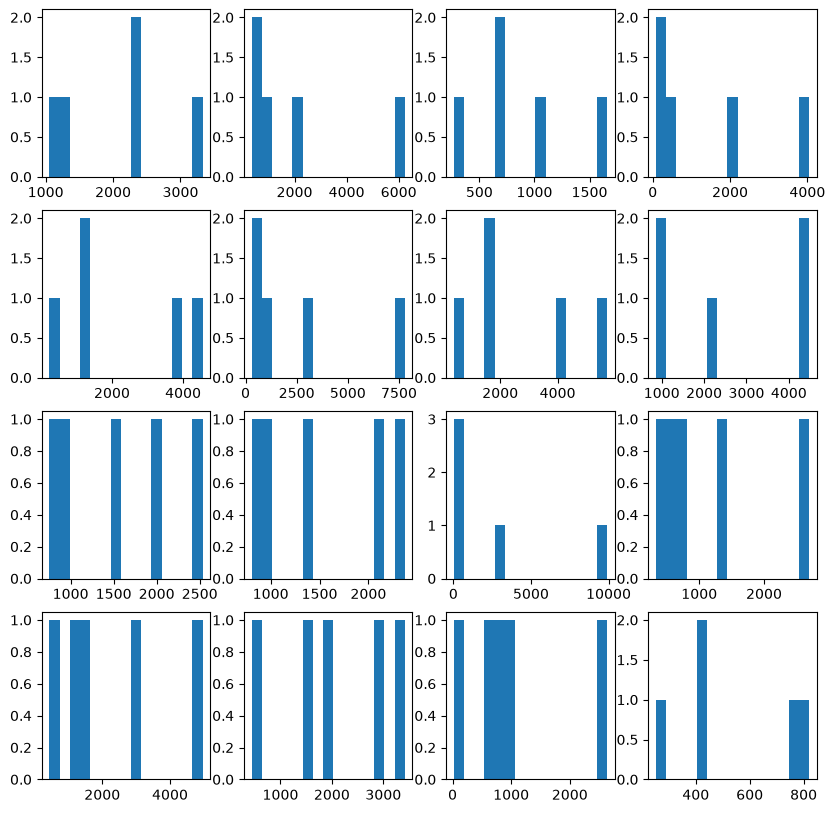

In [266]:
#==============================================#
# PRIOR PREDICTIVE CHECK: MU
#==============================================#
with basic_model:
    prior = pm.sample_prior_predictive()
    fig, axes = plt.subplots(4,4,figsize=(10,10))
    for i, ax in enumerate(axes.flatten()):
        ax.hist(prior.prior["mu"][0][i],bins=15)
        #ax.set_xlim(1500,7500)
    



/var/folders/px/g678_7r10zg5vcsmjzrqblk40000gn/T/ipykernel_7583/2119936007.py:5: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive()
Sampling: [mu, sigma, w]


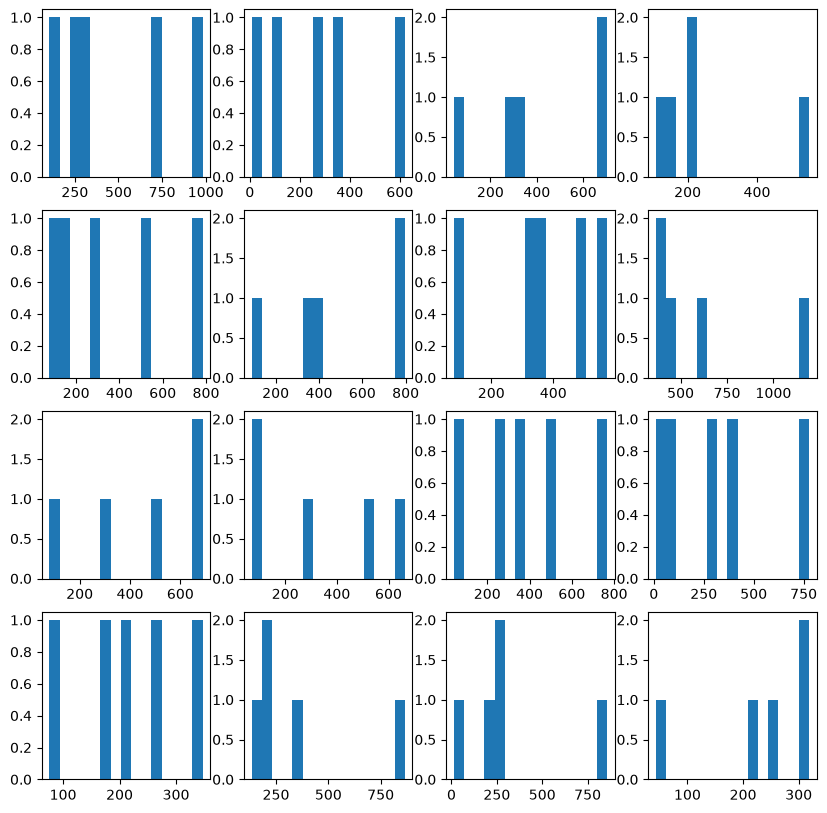

In [267]:
#==============================================#
# PRIOR PREDICTIVE CHECK: SIGMA
#==============================================#
with basic_model:
    prior = pm.sample_prior_predictive()
    fig, axes = plt.subplots(4,4,figsize=(10,10))
    for i, ax in enumerate(axes.flatten()):
        ax.hist(prior.prior["sigma"][0][i],bins=15)
        #ax.set_xlim(1500,7500)
    

/var/folders/px/g678_7r10zg5vcsmjzrqblk40000gn/T/ipykernel_7583/4230594606.py:5: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive()
Sampling: [mu, sigma, w]


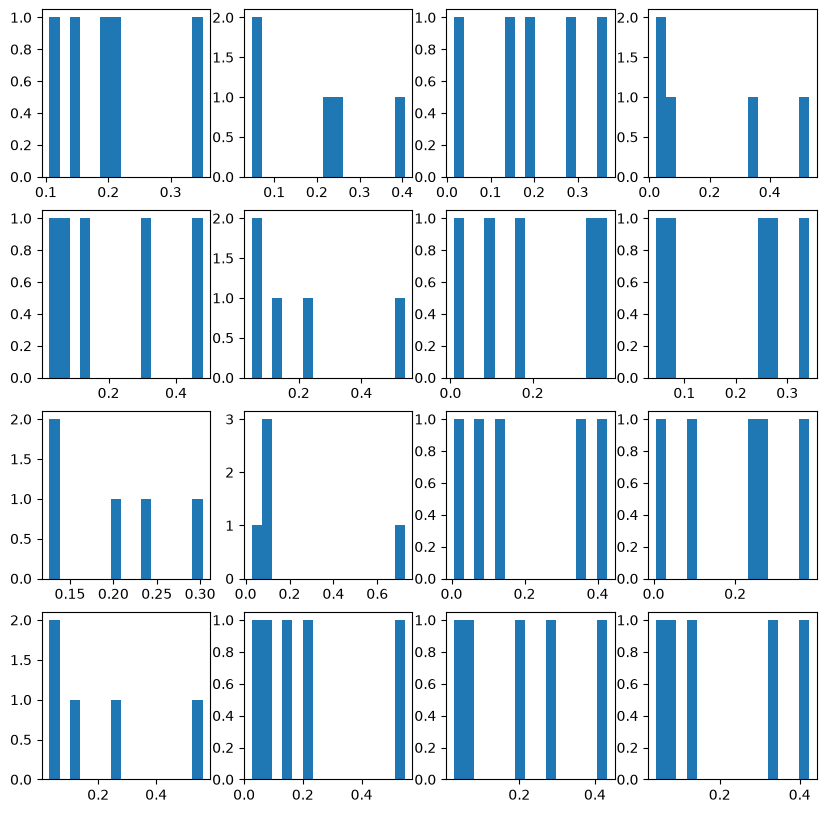

In [268]:
#==============================================#
# PRIOR PREDICTIVE CHECK: WEIGHTS
#==============================================#
with basic_model:
    prior = pm.sample_prior_predictive()
    fig, axes = plt.subplots(4,4,figsize=(10,10))
    for i, ax in enumerate(axes.flatten()):
        ax.hist(prior.prior["w"][0][i],bins=15)
    

In [ ]:
#==============================================#
# PRIOR PREDICTIVE CHECK: CURVE FIT
#==============================================#

#with basic_model:
  #  prior_predictive = pm.sample_prior_predictive(draws=500, random_seed=6740)
    #print(prior_predictive.prior.mixture_density)
  #  print(prior_predictive.prior.w)


    #azp.plot_dist(
    #    prior_predictive.prior.mixture_density
    #)


/var/folders/px/g678_7r10zg5vcsmjzrqblk40000gn/T/ipykernel_7583/427471344.py:6: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior_predictive = pm.sample_prior_predictive(draws=500, random_seed=6740)
Sampling: [mu, sigma, w]


<xarray.DataArray 'w' (chain: 1, draw: 500, w_dim_0: 5)> Size: 20kB
array([[[0.1891777 , 0.34421636, 0.02040554, 0.07478093, 0.37141947],
        [0.10939363, 0.19162523, 0.305926  , 0.37712094, 0.0159342 ],
        [0.57797599, 0.3566153 , 0.00152526, 0.01960161, 0.04428184],
        ...,
        [0.00432325, 0.33968509, 0.15459433, 0.12052575, 0.38087159],
        [0.16338499, 0.2295392 , 0.33540324, 0.03865956, 0.233013  ],
        [0.37344091, 0.0178125 , 0.1144449 , 0.13895763, 0.35534406]]],
      shape=(1, 500, 5))
Coordinates:
  * chain    (chain) int64 8B 0
  * draw     (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
  * w_dim_0  (w_dim_0) int64 40B 0 1 2 3 4


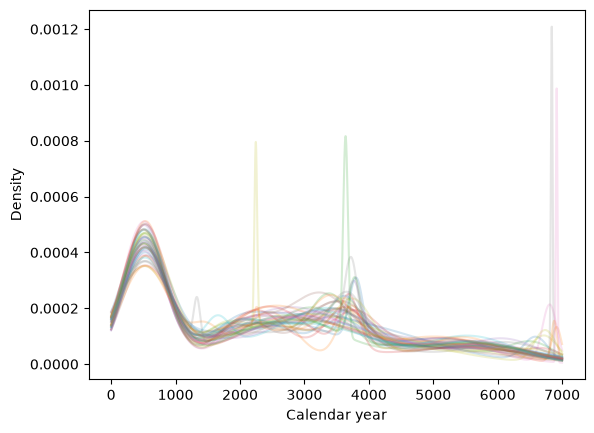

In [293]:
# POSTERIOR CHECK: MIXTURE DENSITIES
density_samples = idata.posterior["mixture_density"].values

for draw in density_samples.reshape(-1, len(calendar_years))[::100]:
    plt.plot(calendar_years, draw, alpha=0.2)

plt.xlabel("Calendar year")
plt.ylabel("Density")
plt.show()

In [291]:
idata.posterior.mixture_density


<xarray.DataArray 'mixture_density' (chain: 4, draw: 1000,
                                     mixture_density_dim_0: 7000)> Size: 224MB
array([[[0.00018493, 0.00018556, 0.0001862 , ..., 0.00001706,
         0.00001704, 0.00001701],
        [0.00014597, 0.00014661, 0.00014726, ..., 0.00002056,
         0.00002051, 0.00002046],
        [0.00013537, 0.00013591, 0.00013645, ..., 0.00002032,
         0.00002028, 0.00002025],
        ...,
        [0.00013251, 0.00013315, 0.00013378, ..., 0.00001489,
         0.00001486, 0.00001483],
        [0.00017661, 0.00017706, 0.00017752, ..., 0.00001541,
         0.00001538, 0.00001535],
        [0.00016281, 0.00016337, 0.00016394, ..., 0.00000876,
         0.00000873, 0.00000869]],

       [[0.00013918, 0.0001398 , 0.00014043, ..., 0.00001446,
         0.00001434, 0.00001423],
        [0.00013139, 0.00013197, 0.00013256, ..., 0.00001401,
         0.0000139 , 0.00001379],
        [0.00012673, 0.00012729, 0.00012785, ..., 0.00005223,
         0.00005215, 0.00005207],
...
        [0.00017753, 0.00017798, 0.00017843, ..., 0.00001479,
         0.00001475, 0.00001471],
        [0.00017278, 0.00017326, 0.00017374, ..., 0.00002164,
         0.0000216 , 0.00002155],
        [0.00014145, 0.00014202, 0.00014259, ..., 0.00001803,
         0.00001799, 0.00001795]],

       [[0.00013285, 0.00013342, 0.00013398, ..., 0.00001555,
         0.00001553, 0.0000155 ],
        [0.00013342, 0.000134  , 0.00013457, ..., 0.00002092,
         0.00002089, 0.00002086],
        [0.00013769, 0.00013834, 0.00013899, ..., 0.00001696,
         0.00001694, 0.00001691],
        ...,
        [0.00012386, 0.00012454, 0.00012522, ..., 0.00003663,
         0.00003659, 0.00003654],
        [0.00014973, 0.00015037, 0.00015102, ..., 0.00001365,
         0.00001362, 0.0000136 ],
        [0.00017432, 0.00017487, 0.00017542, ..., 0.00002048,
         0.00002044, 0.00002041]]], shape=(4, 1000, 7000))
Coordinates:
  * chain                  (chain) int64 32B 0 1 2 3
  * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
  * mixture_density_dim_0  (mixture_density_dim_0) int64 56kB 0 1 ... 6998 6999

# Posterior Predictive Checks.

Posterior predictive checks will be used to assess the agreement between the estimated and observed radiocarbon distribution. Comparisons may include overall shape, variance, and other summary statistics.


## Out-of-Sample Likelihood. 

Leave-one-out cross-validation will be used to estimate the model’s predictive performance. Due to the computational complexity of refitting multiple MCMC models, approximate approaches, such as Pareto-smoothed importance sampling leave-one-out, may be used if appropriate (Vehtari et al., 2018).


## Oversampling Sensitivity Check

See how much estimates change with/without oversampling correction. 

## Comparison Against Archaeological Literature.

Population estimates will be compared against established cultural chronologies from the archaeological literature (e.g., Fitzhugh, 1985). Agreement with known phases and transitions will provide a preliminary check on the validity of the model.
